# 1min

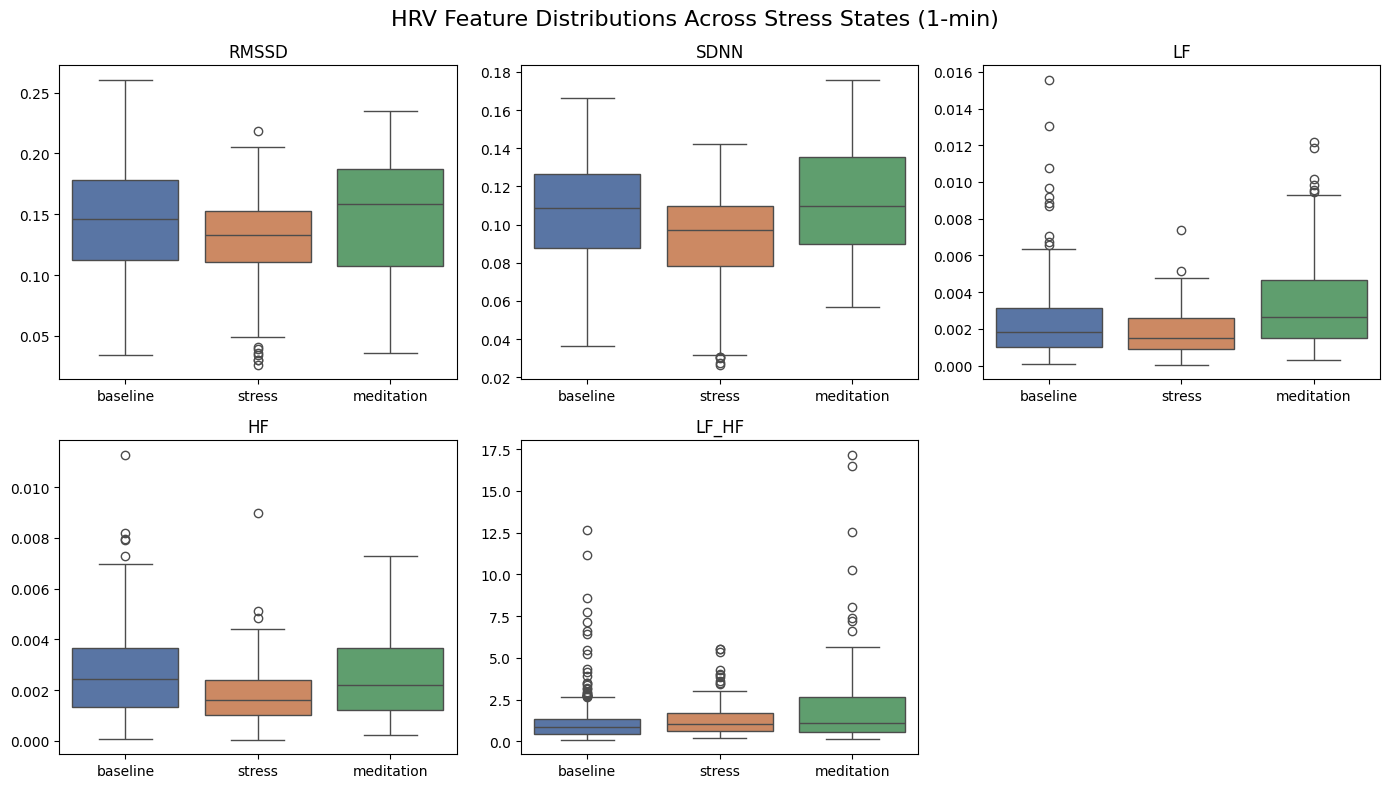


===== HRV 1-min Feature Summary =====
  feature Baseline (mean±std) Stress (mean±std) Meditation (mean±std)  \
0   RMSSD       0.146 ± 0.046     0.128 ± 0.038         0.149 ± 0.050   
1    SDNN       0.107 ± 0.028     0.092 ± 0.026         0.113 ± 0.030   
2      LF       0.002 ± 0.002     0.002 ± 0.001         0.004 ± 0.003   
3      HF       0.003 ± 0.002     0.002 ± 0.001         0.003 ± 0.002   
4   LF_HF       1.240 ± 1.511     1.339 ± 1.072         2.399 ± 3.267   

        anova_p  
0  5.871531e-05  
1  1.936416e-09  
2  2.559888e-09  
3  2.338613e-07  
4  1.729423e-06  


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# load
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BP/HRV-csv/HRV_1min.csv")

# 상태 이름 정리
df["state"] = df["label_major"].map({
    1: "baseline",
    2: "stress",
    4: "meditation"
})

# HRV features
hrv_features = ["RMSSD", "SDNN", "LF", "HF", "LF_HF"]

results = []

# -------------------------
# Figure (5 boxplots)
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(hrv_features):

    data = df[["state", feature]].dropna()

    sns.boxplot(
        x="state",
        y=feature,
        data=data,
        ax=axes[i],
        palette=["#4C72B0", "#DD8452", "#55A868"]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    # 통계
    b = data[data.state == "baseline"][feature]
    s = data[data.state == "stress"][feature]
    m = data[data.state == "meditation"][feature]

    anova = f_oneway(b, s, m)

    # mean std
    summary = data.groupby("state")[feature].agg(["mean", "std"])

    results.append({
        "feature": feature,
        "baseline_mean": summary.loc["baseline", "mean"],
        "baseline_std": summary.loc["baseline", "std"],
        "stress_mean": summary.loc["stress", "mean"],
        "stress_std": summary.loc["stress", "std"],
        "med_mean": summary.loc["meditation", "mean"],
        "med_std": summary.loc["meditation", "std"],
        "anova_p": anova.pvalue
    })

# 남는 subplot 제거 (6칸 중 5개 사용)
fig.delaxes(axes[-1])

plt.suptitle("HRV Feature Distributions Across Stress States (1-min)", fontsize=16)
plt.tight_layout()
plt.show()

# -------------------------
# Table
# -------------------------
results_df = pd.DataFrame(results)

# mean±std 문자열로 정리
results_df["Baseline (mean±std)"] = results_df.apply(
    lambda r: f"{r['baseline_mean']:.3f} ± {r['baseline_std']:.3f}", axis=1)

results_df["Stress (mean±std)"] = results_df.apply(
    lambda r: f"{r['stress_mean']:.3f} ± {r['stress_std']:.3f}", axis=1)

results_df["Meditation (mean±std)"] = results_df.apply(
    lambda r: f"{r['med_mean']:.3f} ± {r['med_std']:.3f}", axis=1)

results_df = results_df[[
    "feature",
    "Baseline (mean±std)",
    "Stress (mean±std)",
    "Meditation (mean±std)",
    "anova_p"
]]

print("\n===== HRV 1-min Feature Summary =====")
print(results_df)

# 2min

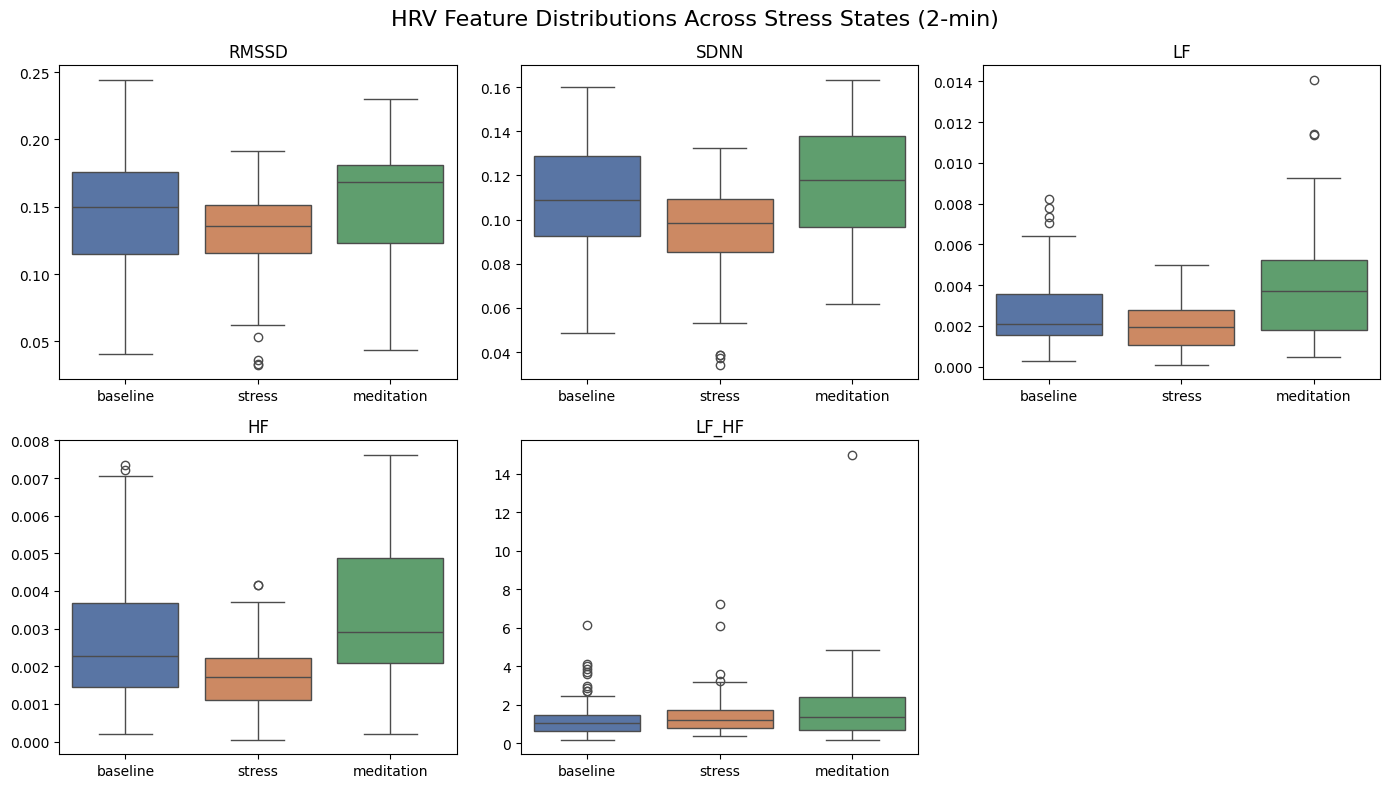


===== HRV 2-min Feature Summary =====
  feature Baseline (mean±std) Stress (mean±std) Meditation (mean±std)  \
0   RMSSD       0.146 ± 0.042     0.127 ± 0.037         0.155 ± 0.046   
1    SDNN       0.109 ± 0.026     0.093 ± 0.024         0.118 ± 0.028   
2      LF       0.003 ± 0.002     0.002 ± 0.001         0.004 ± 0.003   
3      HF       0.003 ± 0.002     0.002 ± 0.001         0.003 ± 0.002   
4   LF_HF       1.214 ± 0.902     1.475 ± 1.149         2.034 ± 2.594   

        anova_p  
0  1.480153e-03  
1  2.112648e-06  
2  6.354721e-08  
3  5.743902e-07  
4  5.695099e-03  


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# load
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BP/HRV-csv/HRV_2min.csv")

# 상태 이름 정리
df["state"] = df["label_major"].map({
    1: "baseline",
    2: "stress",
    4: "meditation"
})

# HRV features
hrv_features = ["RMSSD", "SDNN", "LF", "HF", "LF_HF"]

results = []

# -------------------------
# Figure (5 boxplots)
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(hrv_features):

    data = df[["state", feature]].dropna()

    sns.boxplot(
        x="state",
        y=feature,
        data=data,
        ax=axes[i],
        palette=["#4C72B0", "#DD8452", "#55A868"]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    # 통계
    b = data[data.state == "baseline"][feature]
    s = data[data.state == "stress"][feature]
    m = data[data.state == "meditation"][feature]

    anova = f_oneway(b, s, m)

    # mean std
    summary = data.groupby("state")[feature].agg(["mean", "std"])

    results.append({
        "feature": feature,
        "baseline_mean": summary.loc["baseline", "mean"],
        "baseline_std": summary.loc["baseline", "std"],
        "stress_mean": summary.loc["stress", "mean"],
        "stress_std": summary.loc["stress", "std"],
        "med_mean": summary.loc["meditation", "mean"],
        "med_std": summary.loc["meditation", "std"],
        "anova_p": anova.pvalue
    })

# 남는 subplot 제거 (6칸 중 5개 사용)
fig.delaxes(axes[-1])

plt.suptitle("HRV Feature Distributions Across Stress States (2-min)", fontsize=16)
plt.tight_layout()
plt.show()

# -------------------------
# Table
# -------------------------
results_df = pd.DataFrame(results)

# mean±std 문자열로 정리
results_df["Baseline (mean±std)"] = results_df.apply(
    lambda r: f"{r['baseline_mean']:.3f} ± {r['baseline_std']:.3f}", axis=1)

results_df["Stress (mean±std)"] = results_df.apply(
    lambda r: f"{r['stress_mean']:.3f} ± {r['stress_std']:.3f}", axis=1)

results_df["Meditation (mean±std)"] = results_df.apply(
    lambda r: f"{r['med_mean']:.3f} ± {r['med_std']:.3f}", axis=1)

results_df = results_df[[
    "feature",
    "Baseline (mean±std)",
    "Stress (mean±std)",
    "Meditation (mean±std)",
    "anova_p"
]]

print("\n===== HRV 2-min Feature Summary =====")
print(results_df)